### baseline_04: This iteration will continue to test new features
- Reaching the end of hard features that contain meaningful cartridge-specific variations
- This model will integrate overall length of constructed cartridge (COAL) into its list of features to see if the model continues to improve its mean absolute error without compromising the integrity of the predictions.

In [21]:
import pandas as pd
import numpy as np

In [22]:
df = pd.read_csv("baseline_data_updated.csv")
df.head()

,cartridge,bullet_diameter,bullet_brand,bullet_type,bullet_weight,powder_type,burn_rate_index,charge_weight,velocity_fps,barrel_length,data_source,primer,twist_rate,coal,compressed_load,jump_to_lands,amb_temp,pressure,case_capacity,suppressed
0,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n130,84,21.1,3402,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
1,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n133,89,22.8,3481,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
2,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n135,102,24.7,3514,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
3,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n140,112,26.2,3425,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN
4,223_rem,0.225,barnes,hpfb,36.0,vihtavuori_n540,117,25.8,3301,25.0,vihtavuori,small_rifle_generic,12.0,2.181,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
three_oh_eight = df[df["cartridge"].isin(["308_win"])].copy()

features = ["charge_weight", "bullet_weight", "burn_rate_index", "coal"]
target = ["velocity_fps"]
X = three_oh_eight[features].astype(float)
y = three_oh_eight[target].astype(float)
features

['charge_weight', 'bullet_weight', 'burn_rate_index', 'coal']

In [24]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
coeffs = pd.Series(model.coef_.ravel(), index=features)
intercept = model.intercept_
coeffs, intercept

(charge_weight      45.735636
 bullet_weight      -5.207462
 burn_rate_index    -6.669960
 coal                2.019411
 dtype: float64,
 array([2255.45154476]))

In [28]:
from sklearn.metrics import mean_absolute_error

mean_pred = np.full_like(y, y.mean())
floor_four = mean_absolute_error(y, mean_pred)  # floor mae

preds = model.predict(X)
mae_four = mean_absolute_error(y, preds)  # mae based on model learning from our three features

floor_four, mae_four

(191.9525982565519, 51.508990292266816)

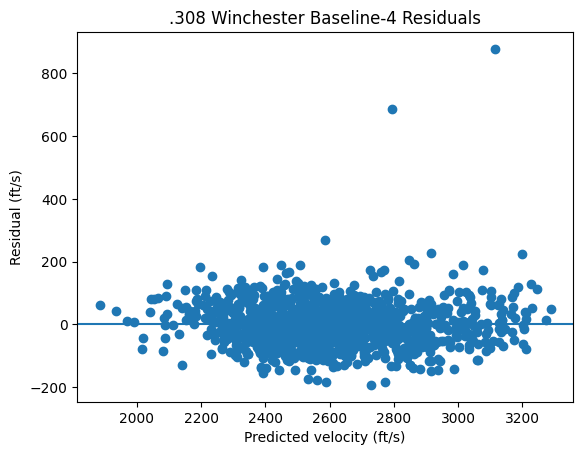

In [27]:
import matplotlib.pyplot as plt

residuals = y - preds

plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title(".308 Winchester Baseline-4 Residuals")
plt.show()

### Interpretation of results
- The model is showing that the added feature has some weight to it, but it is getting lost in the noise and having no contribution to the accuracy of the predictions. I will freeze using simple LinearRegression models at this point and switch to Ridge.
- Discovery from this model: A feature can be physically real and statistically detectable *yet be useless fore prediction of a given dataset.*